In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import entropy

In [3]:
plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4

In [4]:
TAX_COLORS = {
    'S'    : '#ff4444',
    'C'    : '#4444ff',
    'X'    : '#ffaa00',
    'Other': '#44ff44',
}

In [5]:
core_path    = os.getcwd()
results_path = os.path.join(core_path, 'data/results')
plots_path   = os.path.join(core_path, 'plots')
os.makedirs(results_path, exist_ok=True)
os.makedirs(plots_path,   exist_ok=True)
unified_df = pd.read_pickle(os.path.join(results_path, 'unified_df.pkl'))

fam_df = unified_df[unified_df['is_family_member']].copy()

print(f"Family members in unified_df : {len(fam_df):,}")
print(f"Unique families              : {fam_df['family_1'].nunique()}")
print(f"\nBus Class distribution in family members:")
print(fam_df['Bus Class'].value_counts().to_string())

Family members in unified_df : 275
Unique families              : 42

Bus Class distribution in family members:
Bus Class
S      75
Ch     43
C      30
Sq     20
K      17
B      12
V      12
X      11
L       6
Cb      6
Xc      6
Sl      6
Sk      5
Sr      5
Ld      4
Xk      4
Sa      4
Cgh     3
Cg      2
Xe      2
T       1
R       1


In [ ]:
# Fraction of members with dominant class (purity) and normalized Shannon entropy (mixing) for each family at both Main Group and Bus Class levels.
def compute_purity(series):
    if len(series) == 0:
        return np.nan
    return series.value_counts().iloc[0] / len(series)

def compute_entropy(series):
    if len(series) == 0:
        return np.nan
    counts = series.value_counts().values
    probs  = counts / counts.sum()
    n      = len(probs)
    if n == 1:
        return 0.0
    return entropy(probs) / np.log(n)   # normalize to [0,1]

# Compute at BOTH levels for families with 3+ members
min_members = 3

purity_results = []

for fam_id, group in fam_df.groupby('family_1'):
    if len(group) < min_members:
        continue

    # Main Group level
    mg_dominant  = group['Main Group'].value_counts().index[0]
    mg_purity    = compute_purity(group['Main Group'])
    mg_entropy   = compute_entropy(group['Main Group'])
    mg_counts    = dict(group['Main Group'].value_counts())

    # Bus Class level
    bc_dominant  = group['Bus Class'].value_counts().index[0]
    bc_purity    = compute_purity(group['Bus Class'])
    bc_entropy   = compute_entropy(group['Bus Class'])
    bc_counts    = dict(group['Bus Class'].value_counts())

    # Orbital properties
    mean_rms_a   = group['rms_a'].mean()
    mean_lce     = group['LCE'].mean()
    mean_dv      = group['dv_fam_1'].mean()
    mean_ap      = group['a_p'].mean()

    purity_results.append({
        'family_1'      : fam_id,
        'n_members'     : len(group),
        'mean_a_p'      : mean_ap,
        # Main Group level
        'mg_dominant'   : mg_dominant,
        'mg_purity'     : mg_purity,
        'mg_entropy'    : mg_entropy,
        'mg_counts'     : mg_counts,
        # Bus Class level
        'bc_dominant'   : bc_dominant,
        'bc_purity'     : bc_purity,
        'bc_entropy'    : bc_entropy,
        'bc_counts'     : bc_counts,
        # Dynamics
        'mean_rms_a'    : mean_rms_a,
        'mean_lce'      : mean_lce,
        'mean_dv'       : mean_dv,
    })

purity_df = pd.DataFrame(purity_results).sort_values('n_members', ascending=False)

print(f"Families analyzed (3+ members): {len(purity_df)}")
print(f"\n{'Family':<10} {'N':>5} {'MG Purity':>10} {'BC Purity':>10} "
      f"{'MG Dom':>8} {'BC Dom':>8} {'Mean a_p':>10}")
print("-" * 70)
for _, row in purity_df.iterrows():
    print(f"{row['family_1']:<10} {row['n_members']:>5} "
          f"{row['mg_purity']:>10.3f} {row['bc_purity']:>10.3f} "
          f"{row['mg_dominant']:>8} {row['bc_dominant']:>8} "
          f"{row['mean_a_p']:>10.3f}")

Families analyzed (3+ members): 18

Family         N  MG Purity  BC Purity   MG Dom   BC Dom   Mean a_p
----------------------------------------------------------------------
93            35      0.971      0.829        S        S      2.793
668           28      1.000      0.821        C       Ch      2.786
847           22      0.682      0.364        S       Sq      2.776
158           22      1.000      0.682        S        S      2.882
221           21      0.714      0.714    Other        K      3.022
4             19      0.684      0.632    Other        V      2.374
24            15      1.000      0.467        C        B      3.128
15            14      0.786      0.786        S        S      2.643
110           10      0.800      0.700        X        X      2.744
1726          10      0.800      0.400        C        C      2.784
135            8      0.500      0.250        C        B      2.409
145            8      0.875      0.750        C       Ch      2.674
808      

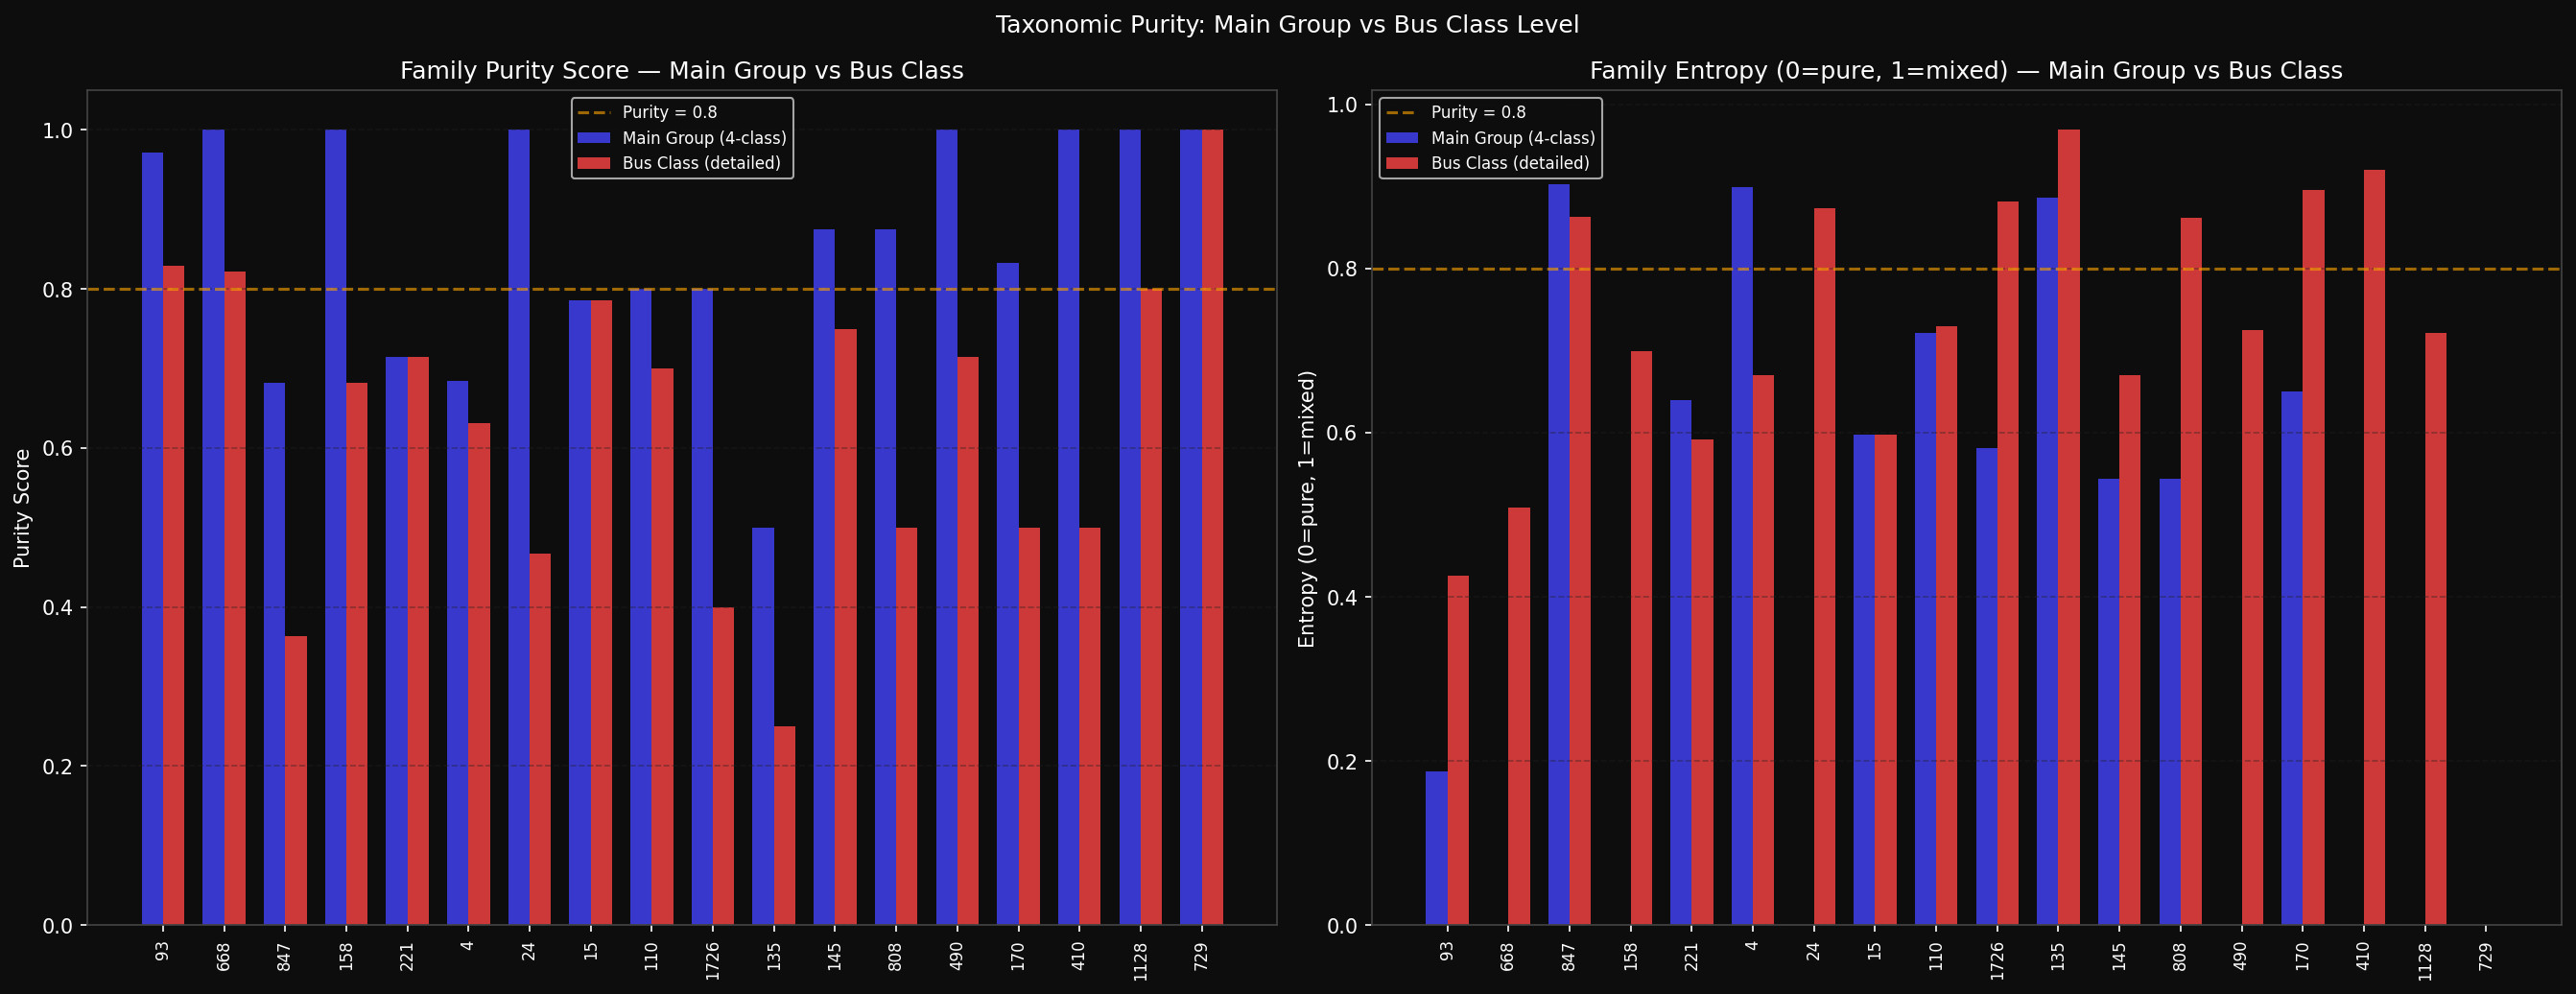

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

fam_labels = purity_df['family_1'].astype(str).values
x          = np.arange(len(purity_df))
width      = 0.35

for ax, (col_mg, col_bc, title) in zip(axes, [
    ('mg_purity', 'bc_purity', 'Purity Score'),
    ('mg_entropy','bc_entropy','Entropy (0=pure, 1=mixed)'),
]):
    bars1 = ax.bar(x - width/2, purity_df[col_mg],
                   width, color='#4444ff', alpha=0.8,
                   label='Main Group (4-class)', edgecolor='none')
    bars2 = ax.bar(x + width/2, purity_df[col_bc],
                   width, color='#ff4444', alpha=0.8,
                   label='Bus Class (detailed)', edgecolor='none')

    ax.axhline(0.8, color='orange', linestyle='--',
               alpha=0.6, label='Purity = 0.8')
    ax.set_xticks(x)
    ax.set_xticklabels(fam_labels, rotation=90, fontsize=8)
    ax.set_ylabel(title)
    ax.set_title(f'Family {title} — Main Group vs Bus Class')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y')

plt.suptitle('Taxonomic Purity: Main Group vs Bus Class Level', fontsize=12)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '03_purity_comparison.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

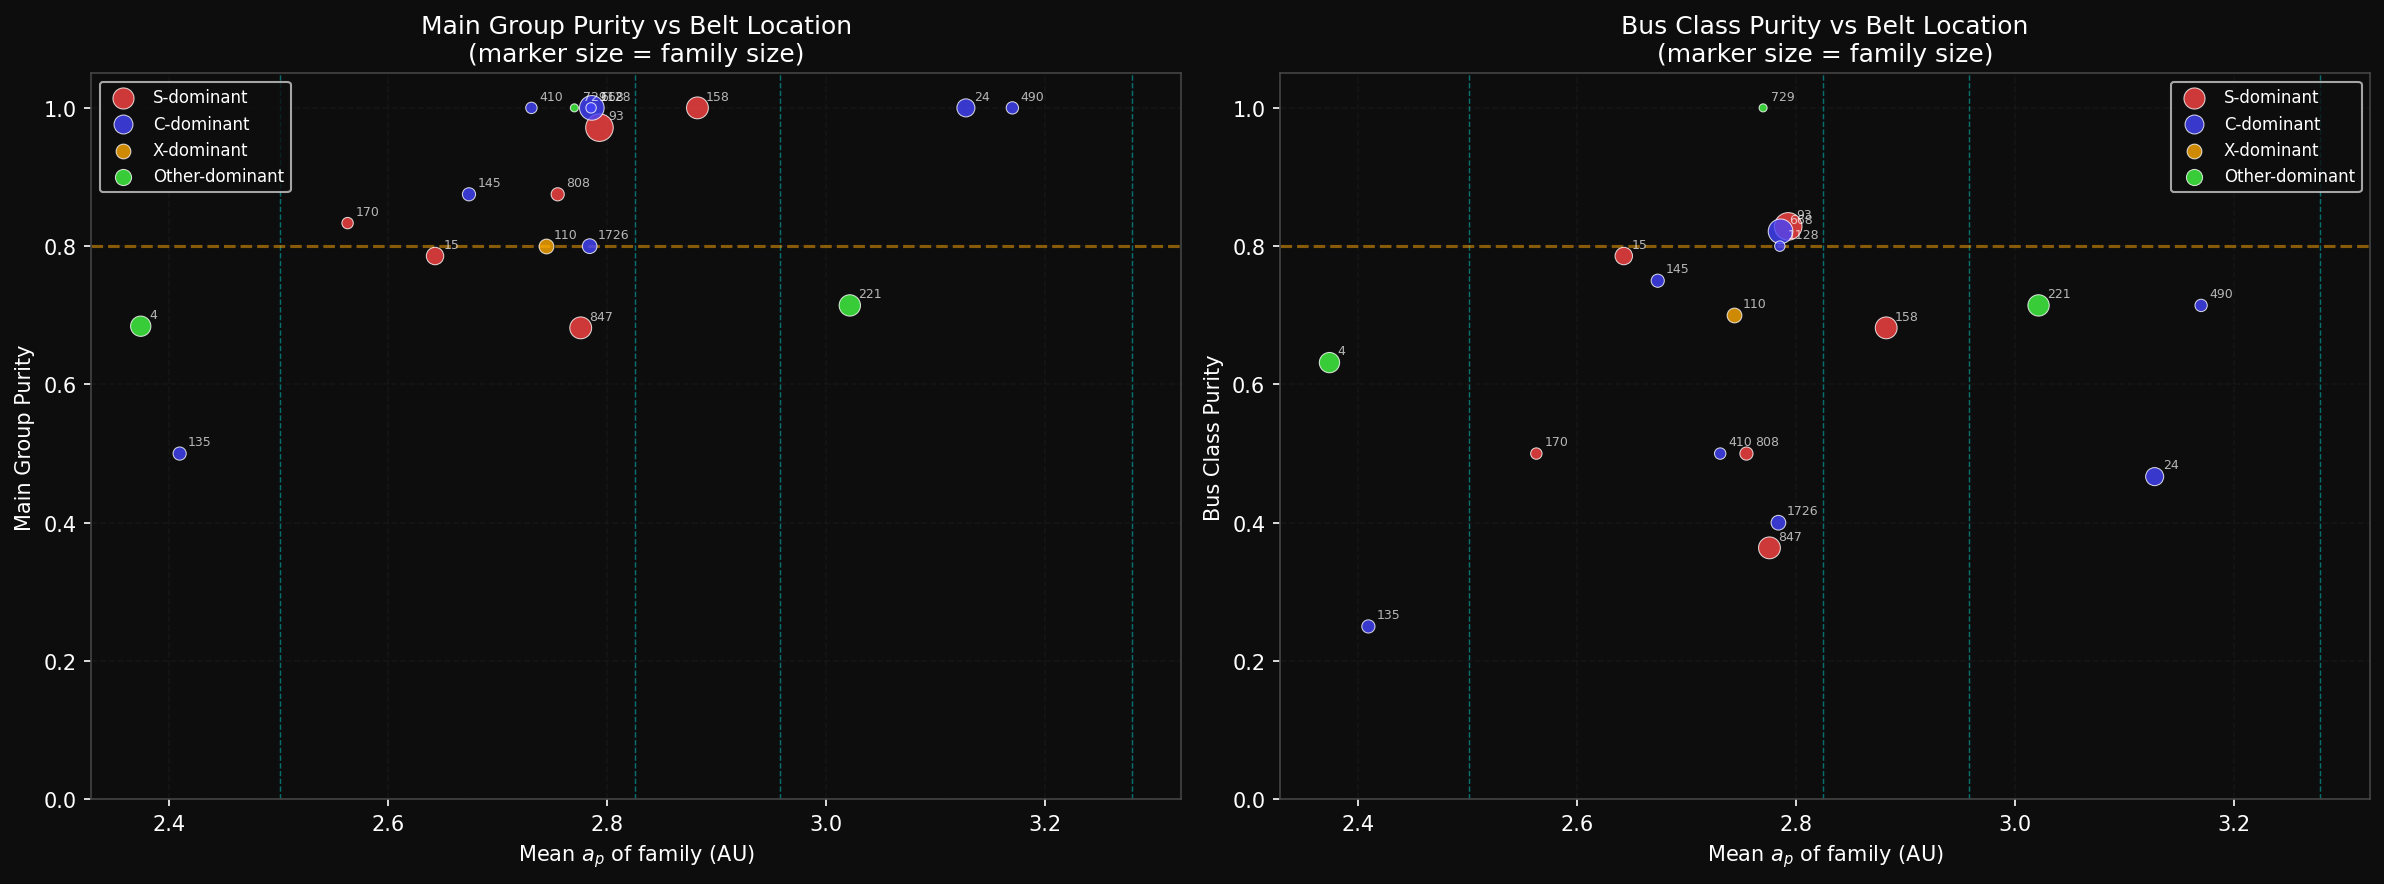

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (col, title) in zip(axes, [
    ('mg_purity', 'Main Group Purity'),
    ('bc_purity', 'Bus Class Purity'),
]):
    # Color points by dominant type
    for group, color in TAX_COLORS.items():
        mask = purity_df['mg_dominant'] == group
        if mask.sum() == 0:
            continue
        ax.scatter(
            purity_df.loc[mask, 'mean_a_p'],
            purity_df.loc[mask, col],
            s=purity_df.loc[mask, 'n_members'] * 5,
            c=color, alpha=0.8, label=f'{group}-dominant',
            linewidths=0.5, edgecolors='white', zorder=3
        )
        # Label family IDs
        for _, row in purity_df[mask].iterrows():
            ax.annotate(str(int(row['family_1'])),
                        (row['mean_a_p'], row[col]),
                        fontsize=6, color='white', alpha=0.7,
                        xytext=(4, 4), textcoords='offset points')

    # Resonances
    resonances = {'3:1': 2.501, '5:2': 2.825, '7:3': 2.958, '2:1': 3.279}
    for name, loc in resonances.items():
        ax.axvline(loc, color='cyan', linewidth=0.7,
                   linestyle='--', alpha=0.4)

    ax.axhline(0.8, color='orange', linestyle='--', alpha=0.5)
    ax.set_xlabel('Mean $a_p$ of family (AU)')
    ax.set_ylabel(title)
    ax.set_title(f'{title} vs Belt Location\n(marker size = family size)')
    ax.legend(fontsize=8)
    ax.grid(True)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '03_purity_vs_location.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

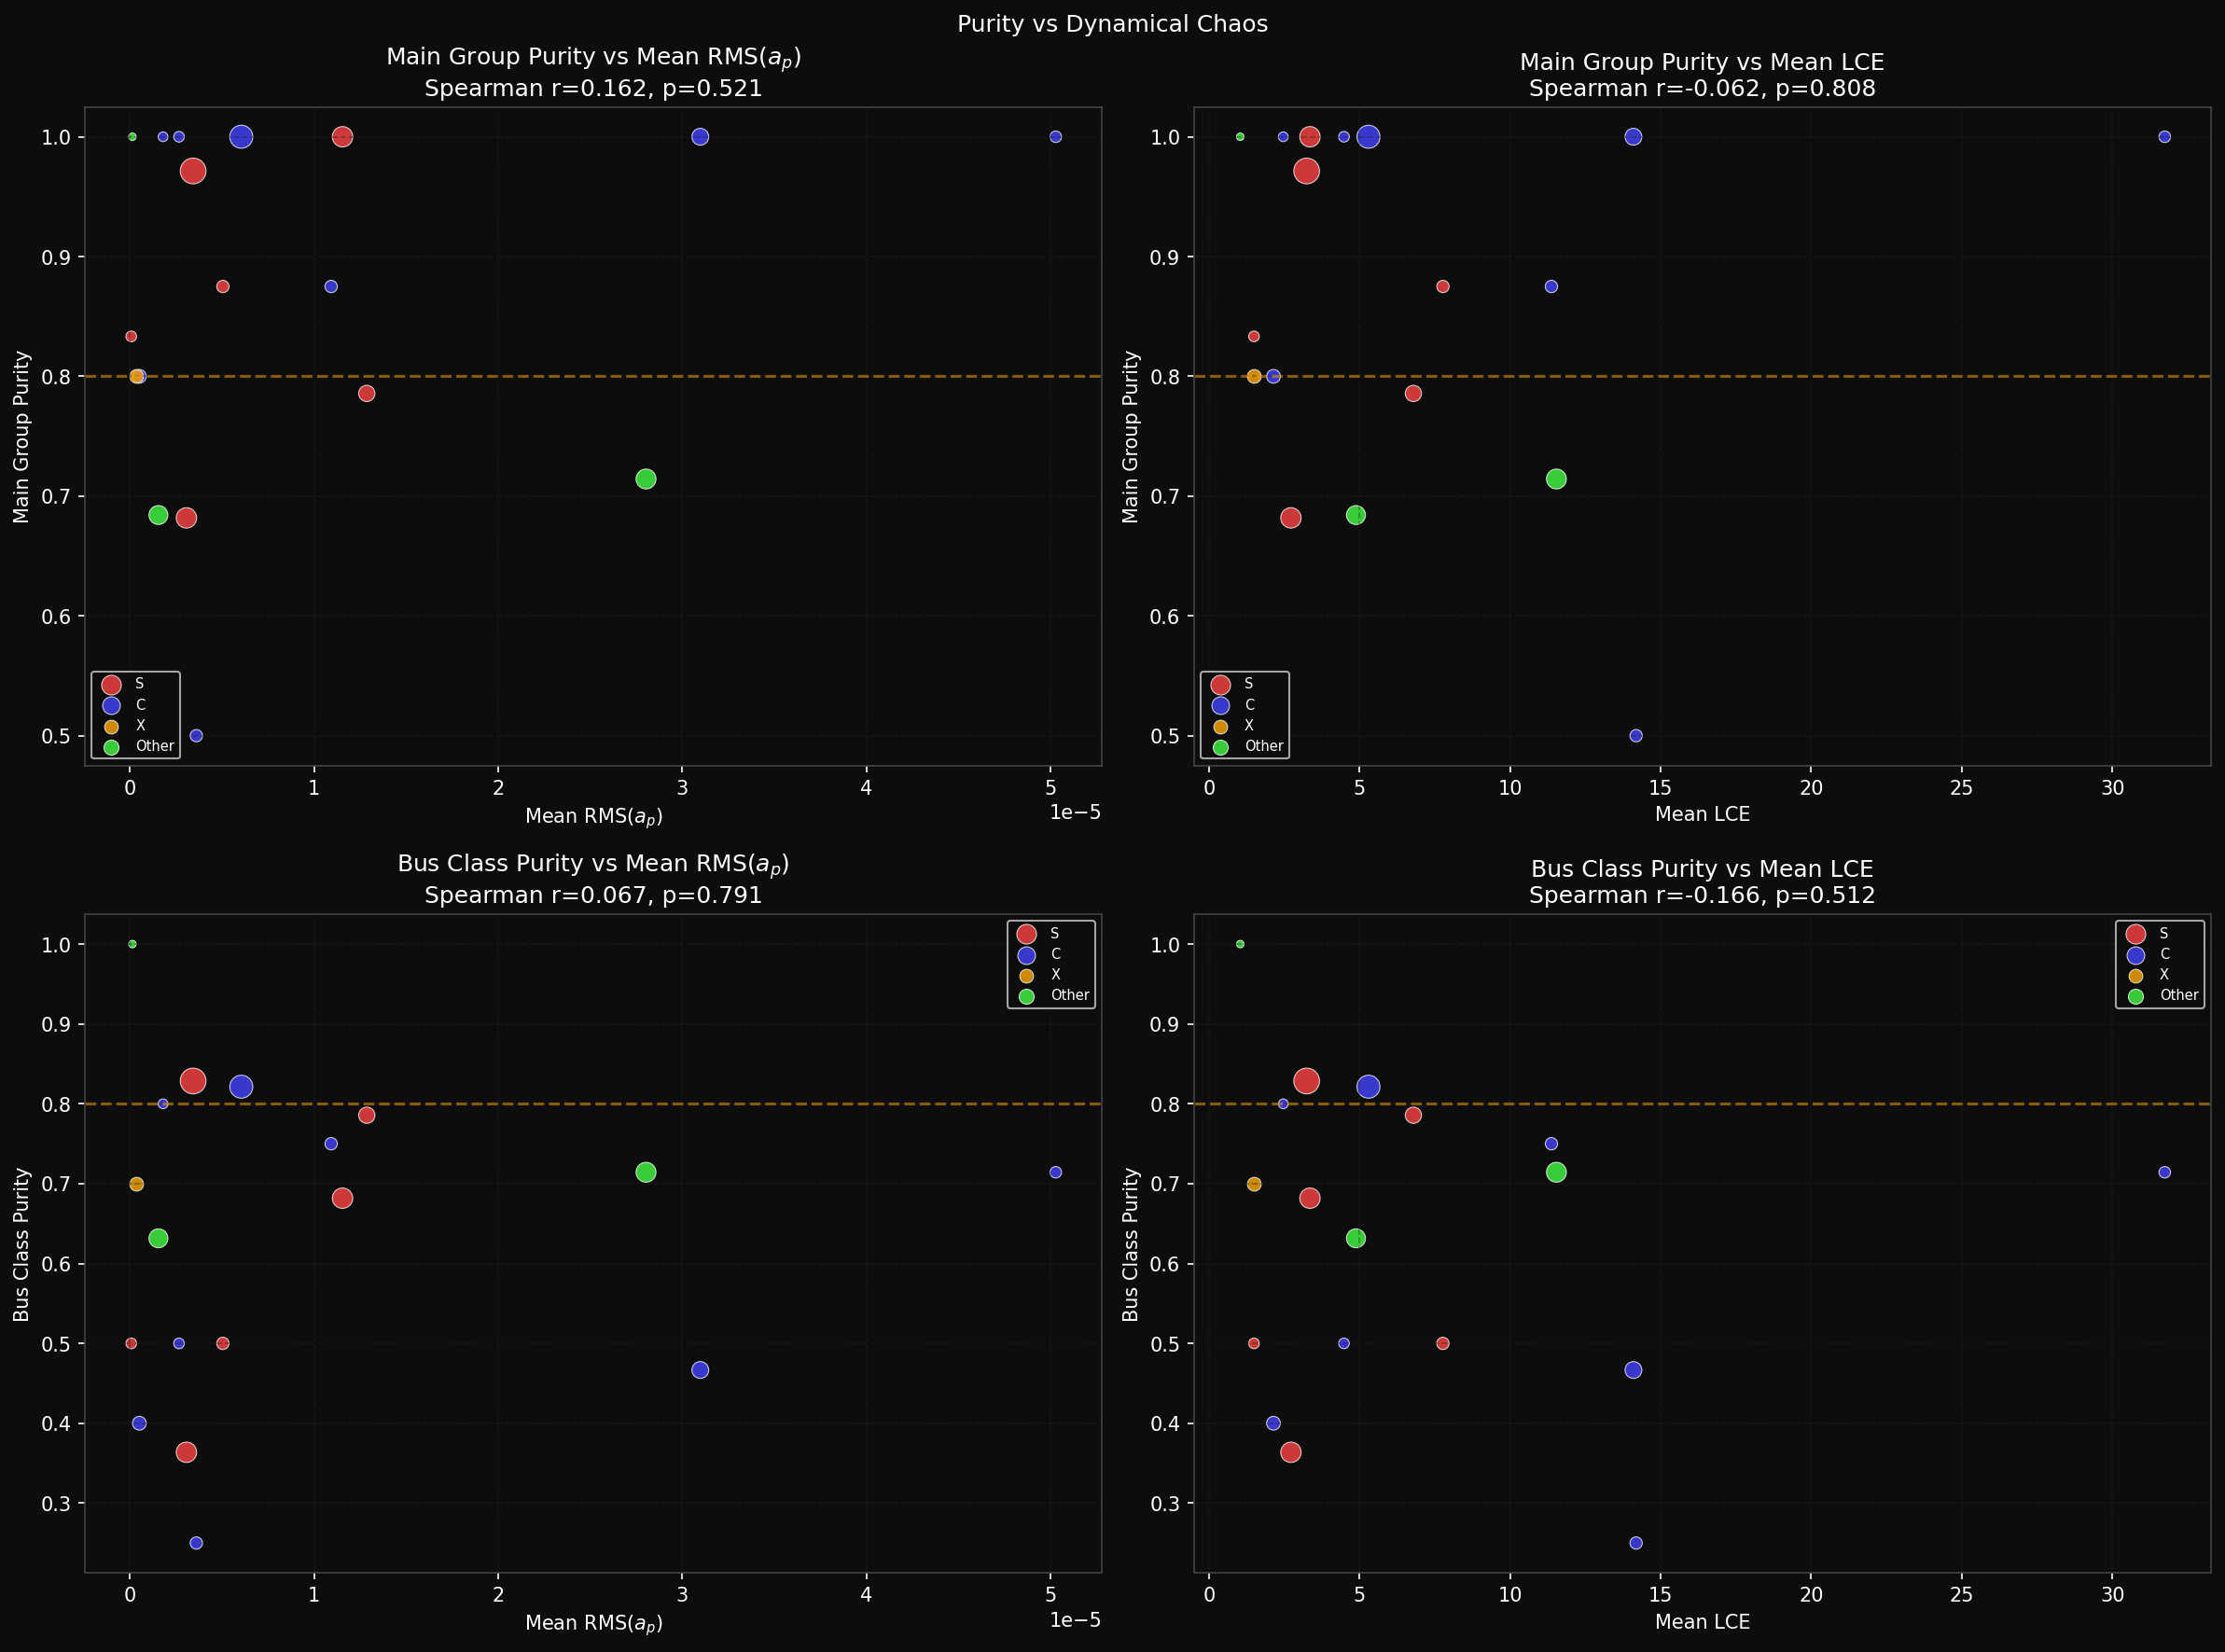

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row_ax, (purity_col, purity_label) in zip(
    [axes[0], axes[1]],
    [('mg_purity', 'Main Group Purity'),
     ('bc_purity', 'Bus Class Purity')]
):
    for ax, (x_col, x_label) in zip(row_ax, [
        ('mean_rms_a', 'Mean RMS($a_p$)'),
        ('mean_lce',   'Mean LCE'),
    ]):
        for group, color in TAX_COLORS.items():
            mask = purity_df['mg_dominant'] == group
            if mask.sum() == 0:
                continue
            ax.scatter(
                purity_df.loc[mask, x_col],
                purity_df.loc[mask, purity_col],
                s=purity_df.loc[mask, 'n_members'] * 5,
                c=color, alpha=0.8, label=f'{group}',
                linewidths=0.5, edgecolors='white'
            )

        # Correlation
        from scipy.stats import spearmanr
        valid = purity_df[[x_col, purity_col]].dropna()
        r, p  = spearmanr(valid[x_col], valid[purity_col])

        ax.set_xlabel(x_label)
        ax.set_ylabel(purity_label)
        ax.set_title(f'{purity_label} vs {x_label}\n'
                     f'Spearman r={r:.3f}, p={p:.3f}')
        ax.legend(fontsize=7)
        ax.grid(True)
        ax.axhline(0.8, color='orange', linestyle='--', alpha=0.5)

plt.suptitle('Purity vs Dynamical Chaos', fontsize=12)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '03_purity_vs_chaos.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

/tmp/ipykernel_9728/158050271.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bus_cmap   = cm.get_cmap('tab20', len(all_bus_classes))


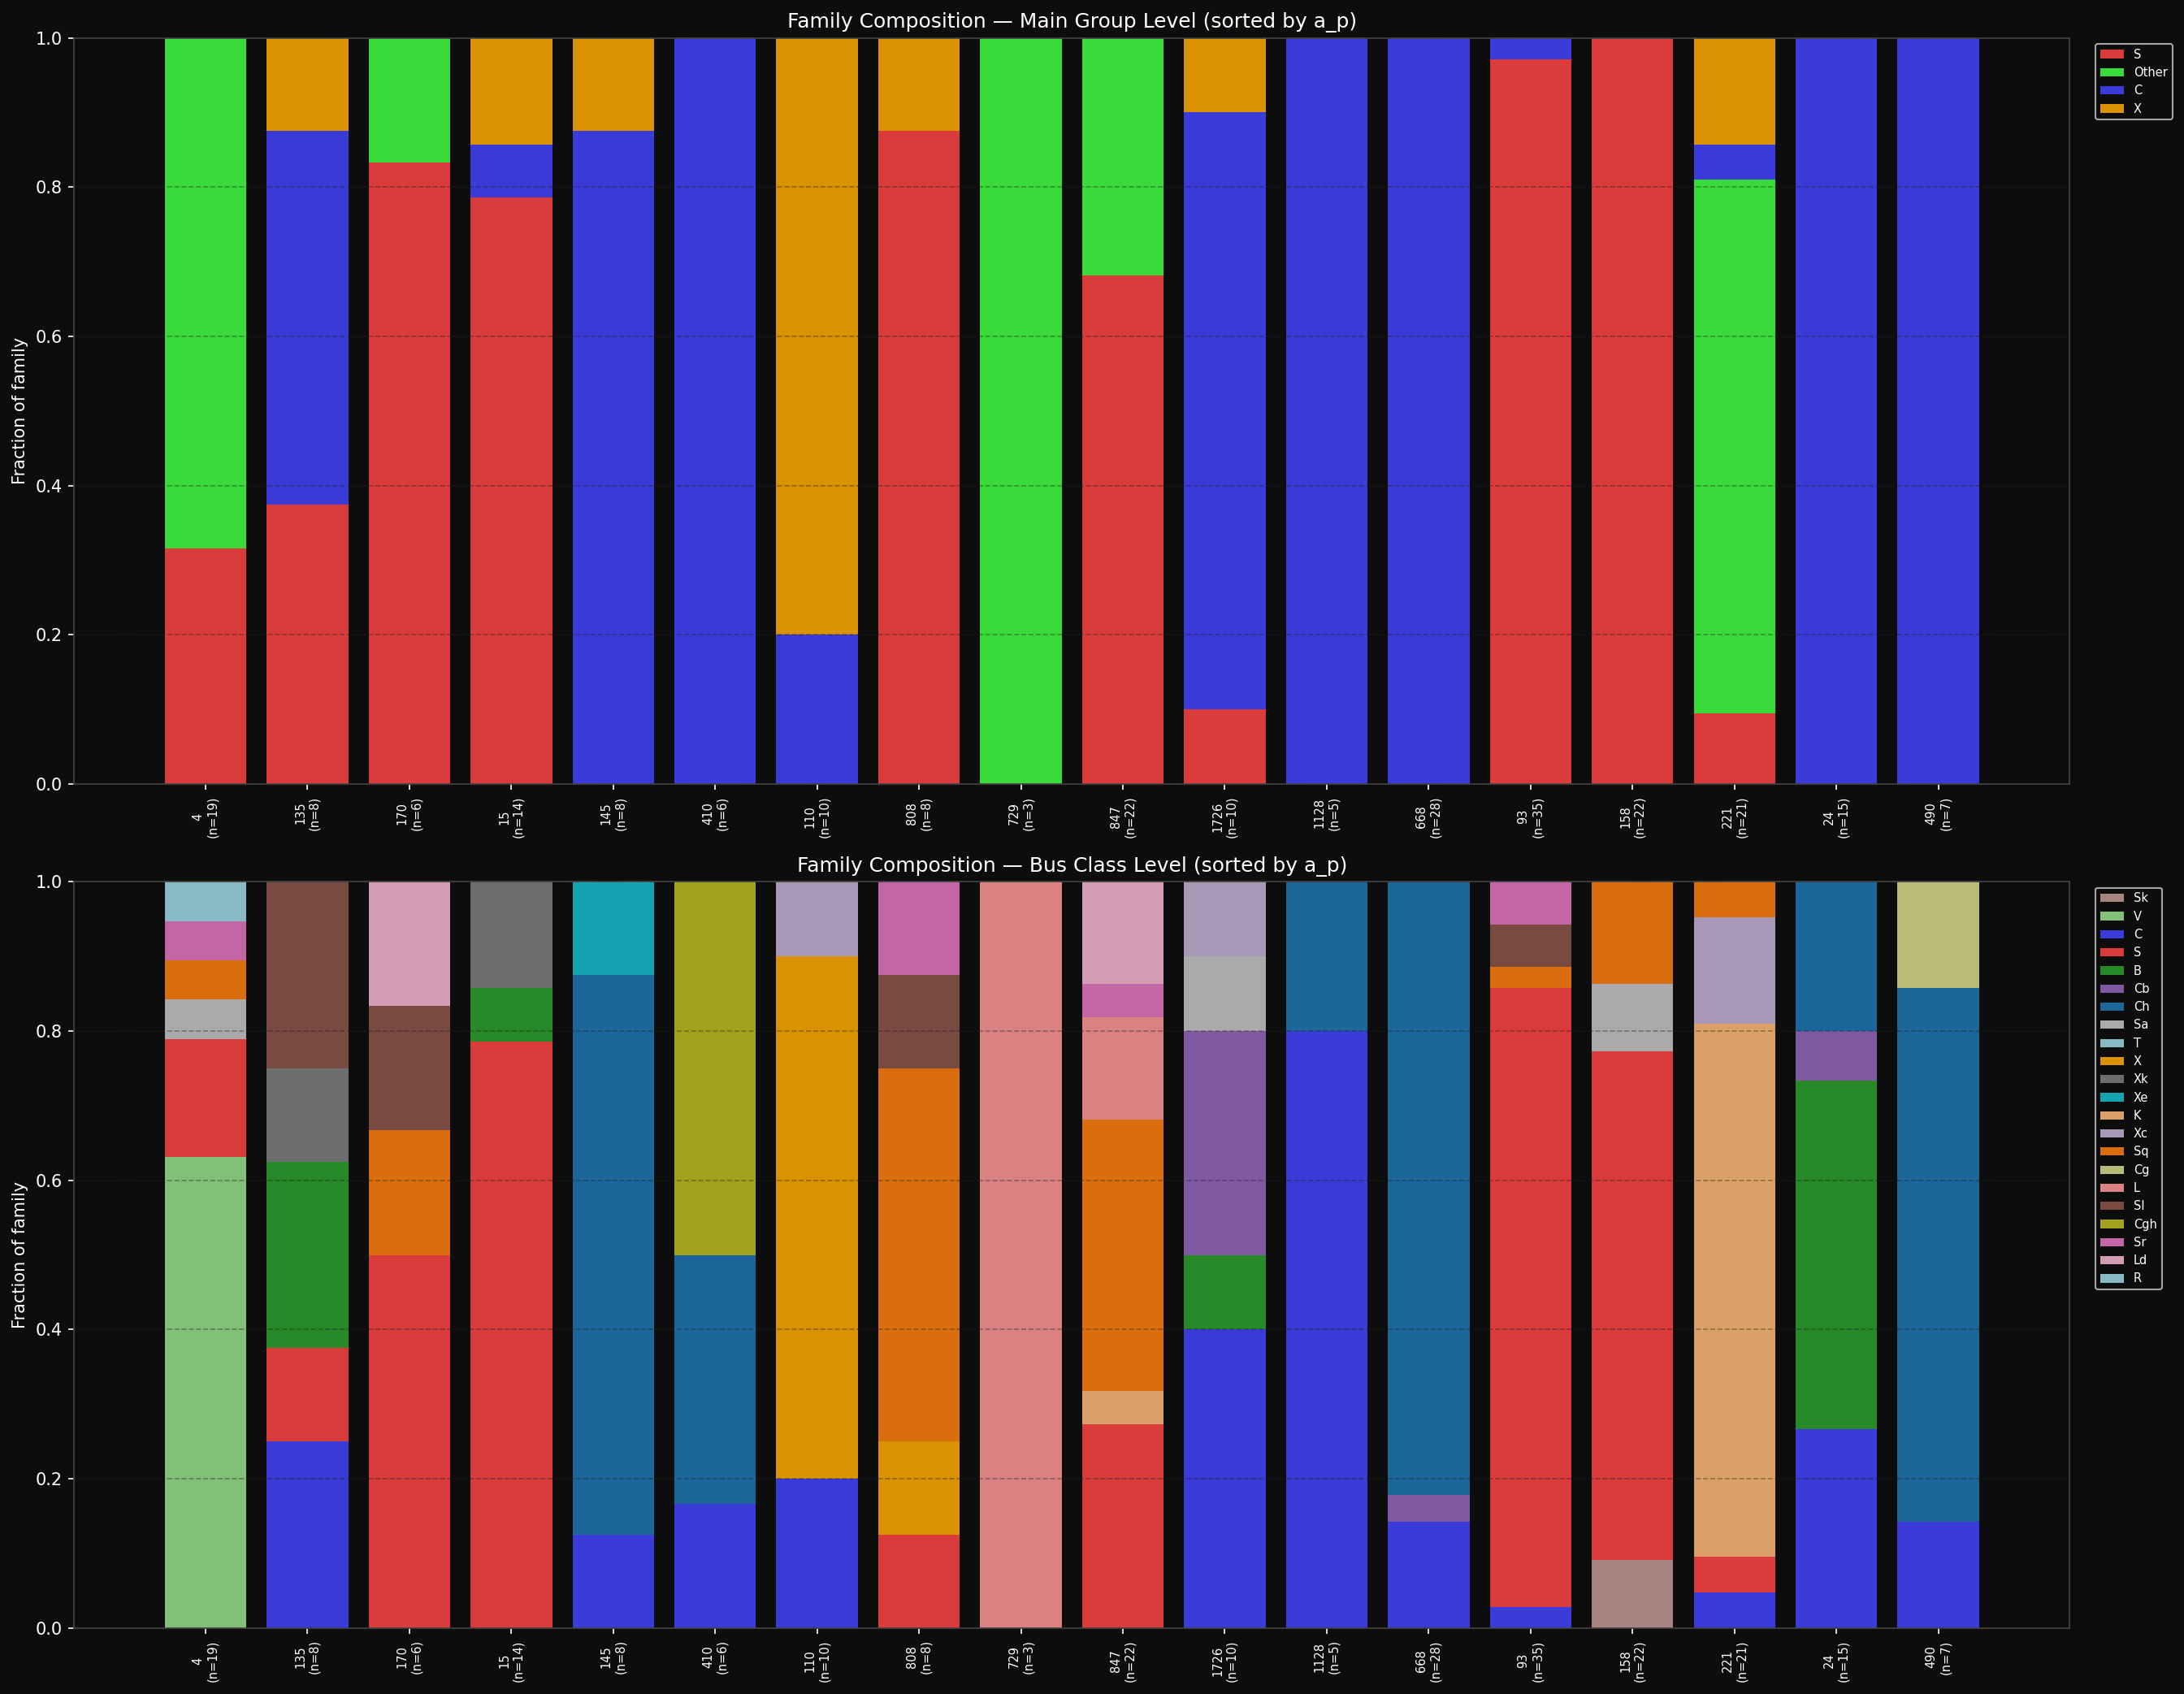

In [10]:
# Use Bus Class for this plot
fig, axes = plt.subplots(2, 1, figsize=(18, 14))

# Get all Bus Classes present in family members
all_bus_classes = fam_df['Bus Class'].value_counts().index.tolist()

# Generate colors for each Bus Class
import matplotlib.cm as cm
bus_cmap   = cm.get_cmap('tab20', len(all_bus_classes))
bus_colors = {bc: bus_cmap(i) for i, bc in enumerate(all_bus_classes)}

for ax, (purity_col, level, class_col, title) in zip(axes, [
    ('mg_purity', 'Main Group', 'Main Group',
     'Family Composition — Main Group Level'),
    ('bc_purity', 'Bus Class',  'Bus Class',
     'Family Composition — Bus Class Level'),
]):
    families_sorted = purity_df.sort_values('mean_a_p')['family_1'].values
    x = np.arange(len(families_sorted))

    bottom = np.zeros(len(families_sorted))
    classes = fam_df[class_col].unique()

    for cls in classes:
        heights = []
        for fam in families_sorted:
            fam_data  = fam_df[fam_df['family_1'] == fam]
            n_total   = len(fam_data)
            n_cls     = (fam_data[class_col] == cls).sum()
            heights.append(n_cls / n_total if n_total > 0 else 0)

        color = TAX_COLORS.get(cls, bus_colors.get(cls, '#888888'))
        ax.bar(x, heights, bottom=bottom,
               color=color, alpha=0.85,
               label=cls, edgecolor='none')
        bottom += np.array(heights)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{int(f)}\n(n={purity_df[purity_df['family_1']==f]['n_members'].values[0]})"
         for f in families_sorted],
        rotation=90, fontsize=7
    )
    ax.set_ylabel('Fraction of family')
    ax.set_title(f'{title} (sorted by a_p)')
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(True, axis='y')

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '03_family_composition_stacked.png'),
#             dpi=200, bbox_inches='tight', bbox_extra_artists=[])
plt.show()

In [11]:
print("=" * 75)
print("TAXONOMIC PURITY ANALYSIS — SUMMARY")
print("=" * 75)

print(f"\nFamilies analyzed : {len(purity_df)}")
print(f"Min members       : {min_members}")

print(f"\n--- Main Group Purity ---")
print(f"  Mean purity   : {purity_df['mg_purity'].mean():.3f}")
print(f"  Median purity : {purity_df['mg_purity'].median():.3f}")
print(f"  Pure (≥0.9)   : {(purity_df['mg_purity'] >= 0.9).sum()} families")
print(f"  Mixed (<0.7)  : {(purity_df['mg_purity'] < 0.7).sum()} families")

print(f"\n--- Bus Class Purity ---")
print(f"  Mean purity   : {purity_df['bc_purity'].mean():.3f}")
print(f"  Median purity : {purity_df['bc_purity'].median():.3f}")
print(f"  Pure (≥0.9)   : {(purity_df['bc_purity'] >= 0.9).sum()} families")
print(f"  Mixed (<0.7)  : {(purity_df['bc_purity'] < 0.7).sum()} families")

print(f"\n--- Key Families ---")
print(f"Most pure (BC)   : "
      f"Family {purity_df.loc[purity_df['bc_purity'].idxmax(), 'family_1']} "
      f"(purity={purity_df['bc_purity'].max():.3f})")
print(f"Most mixed (BC)  : "
      f"Family {purity_df.loc[purity_df['bc_purity'].idxmin(), 'family_1']} "
      f"(purity={purity_df['bc_purity'].min():.3f})")
print(f"\nMG purity > BC purity (Other class inflating MG): "
      f"{(purity_df['mg_purity'] > purity_df['bc_purity']).sum()} families")
print(f"BC purity > MG purity (Bus Class more informative): "
      f"{(purity_df['bc_purity'] > purity_df['mg_purity']).sum()} families")

TAXONOMIC PURITY ANALYSIS — SUMMARY

Families analyzed : 18
Min members       : 3

--- Main Group Purity ---
  Mean purity   : 0.862
  Median purity : 0.875
  Pure (≥0.9)   : 8 families
  Mixed (<0.7)  : 3 families

--- Bus Class Purity ---
  Mean purity   : 0.634
  Median purity : 0.691
  Pure (≥0.9)   : 1 families
  Mixed (<0.7)  : 9 families

--- Key Families ---
Most pure (BC)   : Family 729 (purity=1.000)
Most mixed (BC)  : Family 135 (purity=0.250)

MG purity > BC purity (Other class inflating MG): 15 families
BC purity > MG purity (Bus Class more informative): 0 families


In [12]:
import pickle

purity_save = {
    'purity_df'  : purity_df,
    'min_members': min_members,
}

with open(os.path.join(results_path, '03_purity_results.pkl'), 'wb') as f:
    pickle.dump(purity_save, f)

print("Saved → data/results/03_purity_results.pkl")

Saved → data/results/03_purity_results.pkl


In [ ]:
# Quick preview before next stage
mixed_families = purity_df[purity_df['bc_purity'] < 0.7].sort_values('bc_purity')
print(mixed_families[['family_1', 'n_members', 'bc_purity',
                       'bc_dominant', 'bc_counts', 'mean_a_p']].to_string())

    family_1  n_members  bc_purity bc_dominant                                             bc_counts  mean_a_p
5        135          8   0.250000           B            {'B': 2, 'Sl': 2, 'C': 2, 'Xk': 1, 'S': 1}  2.409496
15       847         22   0.363636          Sq   {'Sq': 8, 'S': 6, 'L': 3, 'Ld': 3, 'Sr': 1, 'K': 1}  2.775779
17      1726         10   0.400000           C           {'C': 4, 'Cb': 3, 'Xc': 1, 'B': 1, 'Sa': 1}  2.783960
2         24         15   0.466667           B                    {'B': 7, 'C': 4, 'Ch': 3, 'Cb': 1}  3.127584
14       808          8   0.500000          Sq           {'Sq': 4, 'X': 1, 'Sr': 1, 'S': 1, 'Sl': 1}  2.754763
8        170          6   0.500000           S                   {'S': 3, 'Sl': 1, 'Ld': 1, 'Sq': 1}  2.562876
10       410          6   0.500000         Cgh                           {'Cgh': 3, 'Ch': 2, 'C': 1}  2.730781
0          4         19   0.631579           V  {'V': 12, 'S': 3, 'Sa': 1, 'Sq': 1, 'Sr': 1, 'R': 1}  2.373935
7

In [21]:
# Define spectral complex mapping
# Groups related Bus subtypes into parent complexes
complex_map = {
    # C complex
    'C': 'C-complex', 'Cb': 'C-complex', 'Ch': 'C-complex',
    'Cg': 'C-complex', 'Cgh': 'C-complex', 'B': 'C-complex',
    # S complex
    'S': 'S-complex', 'Sa': 'S-complex', 'Sq': 'S-complex',
    'Sr': 'S-complex', 'Sk': 'S-complex', 'Sl': 'S-complex',
    'Sv': 'S-complex',
    # X complex
    'X': 'X-complex', 'Xc': 'X-complex', 'Xe': 'X-complex',
    'Xk': 'X-complex',
    # Unique types
    'V': 'V-type', 'A': 'A-type', 'R': 'R-type',
    'K': 'K-type', 'L': 'L-type', 'Ld': 'L-type',
    'D': 'D-type', 'T': 'T-type', 'O': 'O-type',
}

unified_df['Spectral_Complex'] = unified_df['Bus Class'].map(complex_map)
unified_df['Spectral_Complex'] = unified_df['Spectral_Complex'].fillna('Other')

# Resave
unified_df.to_pickle(os.path.join(results_path, 'unified_df.pkl'))

print("Added Spectral_Complex column")
print(unified_df['Spectral_Complex'].value_counts())

Added Spectral_Complex column
Spectral_Complex
S-complex    488
C-complex    357
X-complex    196
L-type        44
V-type        35
K-type        31
T-type        10
A-type        10
D-type         5
R-type         4
O-type         1
Name: count, dtype: int64


In [23]:
# Bus Class level    → finest grain (0.634 mean) — true scientific purity
# Spectral Complex   → middle grain — removes weathering noise
# Main Group level   → coarsest (0.862 mean) — too coarse

# Quick complex-level purity for the 9 mixed families
print("\n=== Complex-level purity for Tier 1-3 families ===\n")

tier_families = [135, 847, 1726, 24, 808, 170, 410, 4, 158]

for fam_id in tier_families:
    group = unified_df[unified_df['family_1'] == fam_id]
    if len(group) == 0:
        continue
    complex_purity   = compute_purity(group['Spectral_Complex'])
    complex_dominant = group['Spectral_Complex'].value_counts().index[0]
    complex_counts   = dict(group['Spectral_Complex'].value_counts())
    bc_purity        = purity_df[purity_df['family_1']==fam_id]['bc_purity'].values[0]

    print(f"Family {fam_id:<6} BC={bc_purity:.3f} → "
          f"Complex={complex_purity:.3f} | "
          f"Dominant: {complex_dominant} | {complex_counts}")


=== Complex-level purity for Tier 1-3 families ===

Family 135    BC=0.250 → Complex=0.500 | Dominant: C-complex | {'C-complex': np.int64(4), 'S-complex': np.int64(3), 'X-complex': np.int64(1)}
Family 847    BC=0.364 → Complex=0.682 | Dominant: S-complex | {'S-complex': np.int64(15), 'L-type': np.int64(6), 'K-type': np.int64(1)}
Family 1726   BC=0.400 → Complex=0.800 | Dominant: C-complex | {'C-complex': np.int64(8), 'X-complex': np.int64(1), 'S-complex': np.int64(1)}
Family 24     BC=0.467 → Complex=1.000 | Dominant: C-complex | {'C-complex': np.int64(15)}
Family 808    BC=0.500 → Complex=0.875 | Dominant: S-complex | {'S-complex': np.int64(7), 'X-complex': np.int64(1)}
Family 170    BC=0.500 → Complex=0.833 | Dominant: S-complex | {'S-complex': np.int64(5), 'L-type': np.int64(1)}
Family 410    BC=0.500 → Complex=1.000 | Dominant: C-complex | {'C-complex': np.int64(6)}
Family 4      BC=0.632 → Complex=0.632 | Dominant: V-type | {'V-type': np.int64(12), 'S-complex': np.int64(6), 'R-ty

In [25]:
# Add tier classification to purity_df
tier_map = {
    135:  1, 847:  1,
    1726: 2, 808:  2, 170: 2, 4: 2,
    24:   3, 410:  3, 158: 3,
}

purity_df['interloper_tier'] = purity_df['family_1'].map(tier_map).fillna(0).astype(int)
# 0 = pure families, no interloper analysis needed
# 1 = Tier 1 priority
# 2 = Tier 2 priority
# 3 = Tier 3 (weathering only)

# Resave purity results
import pickle
with open(os.path.join(results_path, '03_purity_results.pkl'), 'wb') as f:
    pickle.dump({'purity_df': purity_df, 'min_members': 3}, f)

print("Tier classification added:")
print(purity_df[['family_1', 'n_members', 'bc_purity',
                  'complex_purity' if 'complex_purity' in purity_df.columns
                  else 'mg_purity',
                  'interloper_tier']].to_string())

Tier classification added:
    family_1  n_members  bc_purity  mg_purity  interloper_tier
3         93         35   0.828571   0.971429                0
12       668         28   0.821429   1.000000                0
15       847         22   0.363636   0.681818                1
7        158         22   0.681818   1.000000                3
9        221         21   0.714286   0.714286                0
0          4         19   0.631579   0.684211                2
2         24         15   0.466667   1.000000                3
1         15         14   0.785714   0.785714                0
4        110         10   0.700000   0.800000                0
17      1726         10   0.400000   0.800000                2
5        135          8   0.250000   0.500000                1
6        145          8   0.750000   0.875000                0
14       808          8   0.500000   0.875000                2
11       490          7   0.714286   1.000000                0
8        170          6   0.

In [26]:
# Add complex purity to purity_df
complex_purities = []
for fam_id in purity_df['family_1']:
    group = unified_df[unified_df['family_1'] == fam_id]
    complex_purities.append({
        'family_1'        : fam_id,
        'complex_purity'  : compute_purity(group['Spectral_Complex']),
        'complex_dominant': group['Spectral_Complex'].value_counts().index[0],
        'complex_counts'  : dict(group['Spectral_Complex'].value_counts()),
    })

complex_df = pd.DataFrame(complex_purities)
purity_df  = purity_df.merge(complex_df, on='family_1', how='left')

print("Three-level purity summary:")
print(f"{'Family':<10} {'N':>5} {'MG':>8} {'Complex':>10} {'BC':>8} {'Tier':>6}")
print("-" * 50)
for _, row in purity_df.sort_values('n_members', ascending=False).iterrows():
    print(f"{int(row['family_1']):<10} {int(row['n_members']):>5} "
          f"{row['mg_purity']:>8.3f} {row['complex_purity']:>10.3f} "
          f"{row['bc_purity']:>8.3f} {int(row['interloper_tier']):>6}")

Three-level purity summary:
Family         N       MG    Complex       BC   Tier
--------------------------------------------------
93            35    0.971      0.971    0.829      0
668           28    1.000      1.000    0.821      0
847           22    0.682      0.682    0.364      1
158           22    1.000      1.000    0.682      3
221           21    0.714      0.714    0.714      0
4             19    0.684      0.632    0.632      2
24            15    1.000      1.000    0.467      3
15            14    0.786      0.786    0.786      0
110           10    0.800      0.800    0.700      0
1726          10    0.800      0.800    0.400      2
135            8    0.500      0.500    0.250      1
145            8    0.875      0.875    0.750      0
808            8    0.875      0.875    0.500      2
490            7    1.000      1.000    0.714      0
170            6    0.833      0.833    0.500      2
410            6    1.000      1.000    0.500      3
1128           5    

In [28]:
purity_df.columns

Index(['family_1', 'n_members', 'mean_a_p', 'mg_dominant', 'mg_purity',
       'mg_entropy', 'mg_counts', 'bc_dominant', 'bc_purity', 'bc_entropy',
       'bc_counts', 'mean_rms_a', 'mean_lce', 'mean_dv', 'purity_gap',
       'interloper_tier', 'complex_purity', 'complex_dominant',
       'complex_counts'],
      dtype='object')

In [29]:
import pickle

purity_save = {
    'purity_df': purity_df,
    'min_members': min_members,
}

with open(os.path.join(results_path, '03_purity_results.pkl'), 'wb') as f:
    pickle.dump(purity_save, f)

print("Updated purity results saved")

Updated purity results saved
